# ASL Dynamic Signs — Transformer (Modelo Principal)

Este notebook treina um modelo Transformer para reconhecimento de sinais dinâmicos em ASL usando o dataset PopSign do Kaggle (`asl-signs`).

**Dataset esperado:**
```
asl-signs/
├── train.csv
├── sign_to_prediction_index_map.json
└── train_landmarks/
    └── *.parquet
```

> **Nota:** Este notebook usa a mesma pipeline de dados do notebook LSTM. As diferenças estão na arquitetura do modelo e em algumas otimizações adicionais.

## 1. Imports & Configuração

In [7]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Reprodutibilidade ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [8]:
# --- Caminhos ---
DATA_DIR      = Path('/home/luiscunha/Downloads/asl-signs')
LANDMARK_DIR  = DATA_DIR / 'train_landmark_files'
TRAIN_CSV     = DATA_DIR / 'train.csv'
LABEL_MAP     = DATA_DIR / 'sign_to_prediction_index_map.json'

# --- Hiperparâmetros ---
MAX_FRAMES    = 64
BATCH_SIZE    = 64
NUM_EPOCHS    = 40
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
WARMUP_EPOCHS = 5        # warmup linear do learning rate
VAL_SPLIT     = 0.1

# --- Landmarks ---
# Selecção dos 130 landmarks mais relevantes (descobertos pelos vencedores do Kaggle)
# Lábios: 40 landmarks | Mãos: 42 | Pose parcial: 33 | Nariz+Olhos: 15
# Para simplicidade, usamos os 3 tipos principais (sem face)
USE_TYPES = ['left_hand', 'right_hand', 'pose']

## 2. Carregamento de Dados

In [9]:
train_df = pd.read_csv(TRAIN_CSV)
print(f'Total de sequências: {len(train_df)}')
print(f'Total de sinais únicos: {train_df["sign"].nunique()}')
train_df.head()

NUM_TEST_CLASSES = 50
selected_signs = train_df['sign'].unique()[:NUM_TEST_CLASSES]
train_df = train_df[train_df['sign'].isin(selected_signs)].reset_index(drop=True)

Total de sequências: 94477
Total de sinais únicos: 250


In [10]:
#with open(LABEL_MAP, 'r') as f:
 #   sign2idx = json.load(f)

#idx2sign    = {v: k for k, v in sign2idx.items()}

sign2idx = {sign: i for i, sign in enumerate(selected_signs)}
idx2sign = {i: sign for sign, i in sign2idx.items()}
NUM_CLASSES = len(sign2idx)
print(f"Modo de teste: {NUM_CLASSES} classes, {len(train_df)} sequências.")

Modo de teste: 50 classes, 18808 sequências.


## 3. Pré-processamento

In [11]:
def load_landmarks(part_id, seq_id, landmark_dir, use_types, max_frames):
    # Dica: Verifique se o nome da pasta é 'train_landmark_files' ou 'train_landmarks'
    path = landmark_dir / f'{part_id}' / f'{seq_id}.parquet'
    expected_dim = 225 
    
    try:
        df = pd.read_parquet(path)
        df = df[df['type'].isin(use_types)]
        if df.empty: return np.zeros((max_frames, expected_dim), dtype=np.float32), 0
        pivot = df.pivot(index='frame', columns=['type', 'landmark_index'], values=['x', 'y', 'z'])
        pivot = pivot.reorder_levels([1, 2, 0], axis=1).sort_index(axis=1)
        
        arr = pivot.values.astype(np.float32)
        arr = np.nan_to_num(arr, nan=0.0)
        actual_len = len(arr)
    except Exception:
        return np.zeros((max_frames, expected_dim), dtype=np.float32), 0
    # Normalização
    nonzero = arr[arr != 0]
    if len(nonzero) > 0:
        arr[:, 0::3] -= arr[:, 0::3][arr[:, 0::3] != 0].mean()
        arr[:, 1::3] -= arr[:, 1::3][arr[:, 1::3] != 0].mean()
    # Pad/Truncate
    T, F = arr.shape
    if T < max_frames:
        arr = np.concatenate([arr, np.zeros((max_frames - T, F), dtype=np.float32)], axis=0)
    else:
        arr = arr[:max_frames]
        actual_len = max_frames
    return arr, actual_len

In [13]:
# Determinar INPUT_DIM
participant_id = train_df['participant_id'].iloc[0]
sample_id = train_df['sequence_id'].iloc[0]
sample, _ = load_landmarks(participant_id, sample_id, LANDMARK_DIR, USE_TYPES, MAX_FRAMES)
INPUT_DIM  = sample.shape[1]
print(f'Input dim por frame: {INPUT_DIM}')  # left_hand(63) + right_hand(63) + pose(99) = 225

Input dim por frame: 225


## 4. Dataset & DataLoader

In [21]:
class ASLDataset(Dataset):
    def __init__(self, df, landmark_dir, sign2idx, use_types, max_frames, augment=False):
        self.df           = df.reset_index(drop=True)
        self.landmark_dir = Path(landmark_dir)
        self.sign2idx     = sign2idx
        self.use_types    = use_types
        self.max_frames   = max_frames
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def _augment(self, x, real_len):
        # Flip horizontal
        if random.random() < 0.5:
            x = x.clone()
            x[:, 0::3] *= -1

        # Ruído gaussiano
        if random.random() < 0.5:
            x = x + torch.randn_like(x) * 0.01

        # Time masking: apagar alguns frames aleatórios (como SpecAugment)
        if random.random() < 0.3 and real_len > 4:
            mask_len   = random.randint(1, max(1, real_len // 4))
            mask_start = random.randint(0, real_len - mask_len)
            x[mask_start:mask_start + mask_len] = 0.0

        # Feature masking: apagar algumas features aleatoriamente
        if random.random() < 0.3:
            num_features  = x.shape[1]
            mask_features = random.randint(1, max(1, num_features // 8))
            feat_indices  = random.sample(range(num_features), mask_features)
            x[:, feat_indices] = 0.0

        return x

    def __getitem__(self, idx):
        row           = self.df.iloc[idx]
        arr, real_len = load_landmarks(row['participant_id'],
            row['sequence_id'], self.landmark_dir, self.use_types, self.max_frames
        )
        x = torch.tensor(arr, dtype=torch.float32)
        y = self.sign2idx[row['sign']]

        if self.augment:
            x = self._augment(x, real_len)

        # Máscara de padding: True = posição a ignorar no attention
        pad_mask = torch.zeros(self.max_frames, dtype=torch.bool)
        pad_mask[real_len:] = True

        return x, torch.tensor(y, dtype=torch.long), pad_mask

In [22]:
train_split, val_split = train_test_split(
    train_df,
    test_size=VAL_SPLIT,
    stratify=train_df['sign'],
    random_state=SEED
)

print(f'Treino: {len(train_split)} | Validação: {len(val_split)}')

train_ds = ASLDataset(train_split, LANDMARK_DIR, sign2idx, USE_TYPES, MAX_FRAMES, augment=True)
val_ds   = ASLDataset(val_split,   LANDMARK_DIR, sign2idx, USE_TYPES, MAX_FRAMES, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

Treino: 16927 | Validação: 1881


## 5. Modelo Transformer

In [23]:
class PositionalEncoding(nn.Module):
    """
    Positional encoding sinusoidal (Vaswani et al., 2017).
    Alternativa: nn.Embedding aprendido — ambos funcionam bem neste problema.
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe     = torch.zeros(max_len, d_model)
        pos    = torch.arange(0, max_len).unsqueeze(1).float()
        div    = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class ASLTransformerModel(nn.Module):
    """
    Transformer Encoder para reconhecimento de sinais ASL.

    Arquitetura:
        Input → Projeção linear → Positional Encoding
        → N × TransformerEncoderLayer → LayerNorm
        → Global Average Pooling → Classificador MLP

    Features chave:
        - Padding mask para ignorar frames de padding no attention
        - Label smoothing na loss para regularização
        - Positional encoding sinusoidal
    """
    def __init__(
        self,
        input_dim,
        num_classes,
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=512,
        dropout=0.1,
        max_len=512
    ):
        super().__init__()

        # Projeção do espaço de landmarks para d_model
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model)
        )

        self.pos_enc = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        # Stack de TransformerEncoderLayers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True    # Pre-LN: mais estável no treino
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )

        # Token [CLS] aprendido (alternativa ao global average pooling)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Classificador
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x, pad_mask=None):
        # x: (batch, frames, features)
        B, T, _ = x.shape

        # Projeção + positional encoding
        x = self.input_proj(x)   # (B, T, d_model)
        x = self.pos_enc(x)

        # Prepend token [CLS]
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)         # (B, T+1, d_model)

        # Ajustar padding mask para incluir o CLS token (nunca é padding)
        if pad_mask is not None:
            cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            pad_mask = torch.cat([cls_mask, pad_mask], dim=1)  # (B, T+1)

        # Transformer encoder
        x = self.transformer(x, src_key_padding_mask=pad_mask)  # (B, T+1, d_model)

        # Usar o output do token [CLS] para classificação
        cls_out = x[:, 0]  # (B, d_model)

        return self.classifier(cls_out)  # (B, num_classes)


# Instanciar modelo
model = ASLTransformerModel(
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES,
    d_model=256,
    nhead=8,
    num_layers=4,
    dim_feedforward=512,
    dropout=0.1
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {total_params:,}')
print(model)

Parâmetros treináveis: 2,246,194
ASLTransformerModel(
  (input_proj): Sequential(
    (0): Linear(in_features=225, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  

## 6. Treino com Warmup

In [24]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler com warmup linear + cosine decay
def get_scheduler(optimizer, warmup_epochs, total_epochs, steps_per_epoch):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = total_epochs  * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)  # warmup linear
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))  # cosine decay

    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_scheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS, len(train_loader))
print(f'Steps por epoch: {len(train_loader)}')
print(f'Steps de warmup: {WARMUP_EPOCHS * len(train_loader)}')

Steps por epoch: 265
Steps de warmup: 1325


In [25]:
def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for x, y, mask in tqdm(loader, desc='Treino', leave=False):
        x, y, mask = x.to(device), y.to(device), mask.to(device)

        optimizer.zero_grad()
        logits = model(x, pad_mask=mask)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()  # step por batch (não por epoch)

        preds          = logits.argmax(dim=-1)
        total_loss    += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total         += x.size(0)

    return total_loss / total, total_correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0, 0, 0

    for x, y, mask in tqdm(loader, desc='Validação', leave=False):
        x, y, mask = x.to(device), y.to(device), mask.to(device)

        logits = model(x, pad_mask=mask)
        loss   = criterion(logits, y)

        preds          = logits.argmax(dim=-1)
        total_loss    += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total         += x.size(0)

    return total_loss / total, total_correct / total

In [26]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc    = 0.0
best_model_path = 'best_transformer_model.pt'

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler, DEVICE)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion,                       DEVICE)

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        marker = ' ✓ saved'
    else:
        marker = ''

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'LR: {current_lr:.2e}{marker}')

print(f'\nMelhor Val Acc: {best_val_acc:.4f}')

Treino:   0%|          | 0/265 [00:00<?, ?it/s]

Validação:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 01/40 | Train Loss: 3.9168 Acc: 0.0222 | Val Loss: 3.8921 Acc: 0.0404 | LR: 6.00e-05 ✓ saved


Treino:   0%|          | 0/265 [00:00<?, ?it/s]

Validação:   0%|          | 0/30 [00:00<?, ?it/s]

...

Validação:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 39/40 | Train Loss: 1.3270 Acc: 0.8105 | Val Loss: 1.5306 Acc: 0.7544 | LR: 6.04e-07 ✓ saved


Treino:   0%|          | 0/265 [00:00<?, ?it/s]

Validação:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 40/40 | Train Loss: 1.3296 Acc: 0.8096 | Val Loss: 1.5307 Acc: 0.7544 | LR: 0.00e+00

Melhor Val Acc: 0.7544


## 7. Resultados

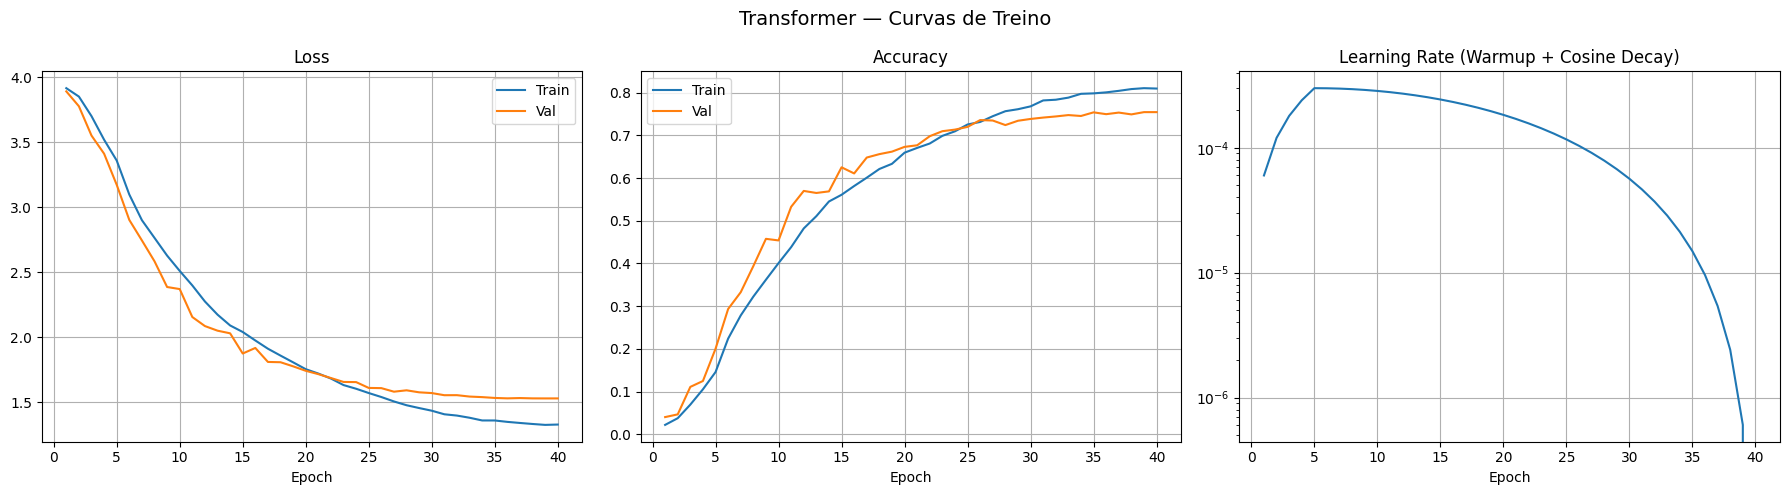

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs_range, history['lr'])
axes[2].set_title('Learning Rate (Warmup + Cosine Decay)')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
axes[2].grid(True)

plt.suptitle('Transformer — Curvas de Treino', fontsize=14)
plt.tight_layout()
plt.savefig('transformer_training_curves.png', dpi=150)
plt.show()

In [28]:
# Avaliação detalhada com o melhor modelo
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x, y, mask in tqdm(val_loader, desc='Avaliação final'):
        x, mask = x.to(DEVICE), mask.to(DEVICE)
        logits  = model(x, pad_mask=mask)
        probs   = F.softmax(logits, dim=-1)
        preds   = logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(y.tolist())
        all_probs.extend(probs.cpu().tolist())

final_acc = accuracy_score(all_labels, all_preds)
print(f'Accuracy final (melhor modelo): {final_acc:.4f}')

# Top-5 accuracy
probs_tensor = torch.tensor(all_probs)
labels_tensor = torch.tensor(all_labels)
top5 = probs_tensor.topk(5, dim=1).indices
top5_acc = (top5 == labels_tensor.unsqueeze(1)).any(dim=1).float().mean().item()
print(f'Top-5 Accuracy: {top5_acc:.4f}')

Avaliação final:   0%|          | 0/30 [00:00<?, ?it/s]

Accuracy final (melhor modelo): 0.7544
Top-5 Accuracy: 0.9038


In [29]:
# Sinais com menor e maior F1
report = classification_report(
    all_labels, all_preds,
    target_names=[idx2sign[i] for i in range(NUM_CLASSES)],
    output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:-3]

print('10 sinais com menor F1:')
print(report_df.sort_values('f1-score').head(10)[['precision', 'recall', 'f1-score', 'support']].to_string())

print('\n10 sinais com maior F1:')
print(report_df.sort_values('f1-score', ascending=False).head(10)[['precision', 'recall', 'f1-score', 'support']].to_string())

10 sinais com menor F1:
        precision    recall  f1-score  support
finger   0.486486  0.473684  0.480000     38.0
vacuum   0.500000  0.580645  0.537313     31.0
owie     0.575758  0.527778  0.550725     36.0
fall     0.666667  0.526316  0.588235     38.0
there    0.720000  0.500000  0.590164     36.0
puzzle   0.617647  0.617647  0.617647     34.0
zipper   0.612903  0.633333  0.622951     30.0
go       0.676471  0.589744  0.630137     39.0
cry      0.625000  0.641026  0.632911     39.0
drawer   0.648649  0.648649  0.648649     37.0

10 sinais com maior F1:
        precision    recall  f1-score  support
see      0.900000  0.923077  0.911392     39.0
owl      0.860465  0.925000  0.891566     40.0
clown    0.853659  0.897436  0.875000     39.0
wake     0.875000  0.875000  0.875000     40.0
flower   0.875000  0.875000  0.875000     40.0
cute     0.800000  0.947368  0.867470     38.0
TV       0.850000  0.871795  0.860759     39.0
bird     0.891892  0.825000  0.857143     40.0
hungry   0.

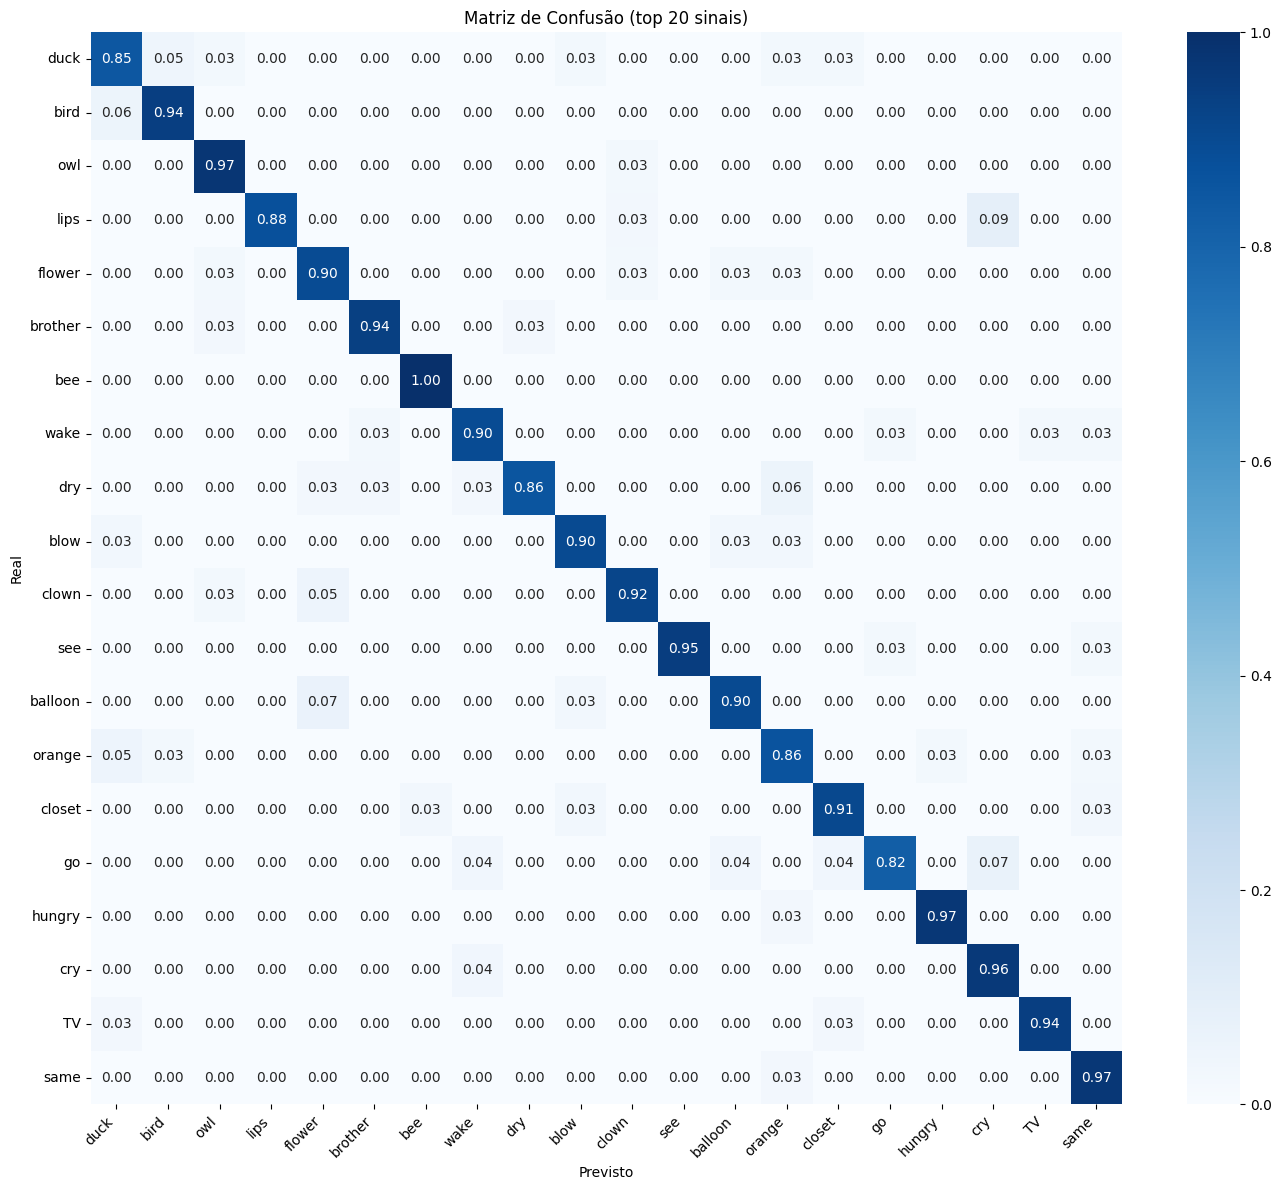

In [32]:
# Matriz de confusão (top 20 sinais para visualização)
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Selecionar os 20 sinais com mais amostras na validação
top20_signs = report_df.sort_values('support', ascending=False).head(20).index.tolist()
top20_idx   = [sign2idx[s] for s in top20_signs]

mask_top20  = [l in top20_idx for l in all_labels]
labels_20   = [all_labels[i] for i in range(len(all_labels)) if mask_top20[i]]
preds_20    = [all_preds[i]  for i in range(len(all_preds))  if mask_top20[i]]

cm = confusion_matrix(labels_20, preds_20, labels=top20_idx)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top20_signs, yticklabels=top20_signs)
plt.title('Matriz de Confusão (top 20 sinais)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('transformer_confusion_matrix.png', dpi=150)
plt.show()

In [33]:
# Guardar modelo final com todos os metadados necessários para inferência
torch.save({
    'model_state_dict': model.state_dict(),
    'sign2idx':    sign2idx,
    'idx2sign':    idx2sign,
    'input_dim':   INPUT_DIM,
    'num_classes': NUM_CLASSES,
    'max_frames':  MAX_FRAMES,
    'use_types':   USE_TYPES,
    'val_acc':     best_val_acc,
    'top5_acc':    top5_acc,
    'model_config': {
        'd_model': 256, 'nhead': 8, 'num_layers': 4,
        'dim_feedforward': 512, 'dropout': 0.1
    }
}, 'asl_transformer_final.pt')

print('Modelo guardado em asl_transformer_final.pt')
print(f'\nResultados finais:')
print(f'  Val Accuracy: {best_val_acc:.4f}')
print(f'  Top-5 Accuracy: {top5_acc:.4f}')

Modelo guardado em asl_transformer_final.pt

Resultados finais:
  Val Accuracy: 0.7544
  Top-5 Accuracy: 0.9038


## 8. Inferência em Tempo Real

Exemplo de como usar o modelo treinado para inferência numa nova sequência.

In [38]:
def predict_sign(part_id,seq_id, model, landmark_dir, use_types, max_frames, idx2sign, device):
    """Faz previsão para uma sequência e devolve top-5 sinais com probabilidades."""
    model.eval()

    arr, real_len = load_landmarks(part_id, seq_id, landmark_dir, use_types, max_frames)
    x        = torch.tensor(arr, dtype=torch.float32).unsqueeze(0).to(device)  # (1, T, F)
    pad_mask = torch.zeros(1, max_frames, dtype=torch.bool).to(device)
    pad_mask[0, real_len:] = True

    with torch.no_grad():
        logits = model(x, pad_mask=pad_mask)
        probs  = F.softmax(logits, dim=-1).squeeze(0)

    top5_probs, top5_idx = probs.topk(5)
    results = [(idx2sign[i.item()], p.item()) for i, p in zip(top5_idx, top5_probs)]
    return results


# Testar numa sequência aleatória da validação
test_row  = val_split.sample(1).iloc[0]
true_sign = test_row['sign']
part_id   = test_row['participant_id']
seq_id    = test_row['sequence_id']

predictions = predict_sign(part_id, seq_id, model, LANDMARK_DIR, USE_TYPES, MAX_FRAMES, idx2sign, DEVICE)

print(f'Sinal real: {true_sign}')
print(f'\nTop-5 previsões:')
for sign, prob in predictions:
    marker = ' ← CORRETO' if sign == true_sign else ''
    print(f'  {sign:<20} {prob:.4f}{marker}')

Sinal real: giraffe

Top-5 previsões:
  giraffe              0.7192 ← CORRETO
  another              0.0396
  there                0.0383
  brother              0.0317
  milk                 0.0301
